# Road Surface Classification — (Auto encoder) Vibration Embedding & Clustering

## 1. Install & Imports <a id='1'></a>

In [19]:
import glob
import pandas as pd
import numpy as np
import os
import glob
import re
import matplotlib.pyplot as plt
import random
from pathlib import Path
from tqdm import tqdm
from scipy.fft import fft
import scipy.stats as stats

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import numpy as np


from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score


# Config

In [20]:
CONFIG = {
    'data_dir': Path('../Datasets/Processed_Data/Labeled_Data_Without_GPS'),
    'window_size': 1024,
    'overlap': 0.5,
    'pca_variance_threshold': 0.95
}

# Loading Data

In [21]:
def extract_surface_type_id(path):
    match = re.search(r'SurfaceTypeID_(\d+)', path)
    return int(match.group(1)) if match else None

data_dir = CONFIG['data_dir']
file_paths = glob.glob(os.path.join(data_dir, "**", "*.csv"), recursive=True)

files_df = pd.DataFrame({
    "full_path": file_paths,
    "filename": [os.path.basename(p) for p in file_paths],
})

files_df["surface_id"] = files_df["full_path"].apply(extract_surface_type_id)
files_df["device"] = files_df["filename"].apply(lambda x: x.split('_')[3])
files_df = files_df[files_df["device"] == "SamsungGalaxyJ7"]

print(files_df["surface_id"].value_counts())

files_df.head(2)

surface_id
9     150
10    150
8      38
7      36
6      36
2      23
5      22
3      20
4      10
Name: count, dtype: int64


,full_path,filename,surface_id,device
0,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-02-15_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9,SamsungGalaxyJ7
2,../Datasets/Processed_Data/Labeled_Data_Withou...,2019-02-05_SurfaceTypeID_9_SamsungGalaxyJ7_exp...,9,SamsungGalaxyJ7


# Basic feature extraction

In [22]:

# Feature extraction code goes here (not shown in the provided snippets)

def zero_crossing_rate(signal):
    return ((signal[:-1] * signal[1:]) < 0).sum()

acc_windows = []
acc_labels = []

gyro_windows = []
gyro_labels = []

WINDOW_SIZE = CONFIG['window_size']
STEP_SIZE = int(WINDOW_SIZE * (1 - CONFIG['overlap']))

for idx, row in tqdm(files_df.iterrows(), total=len(files_df), desc="Processing files"):
    file_path = row['full_path']
    surface_id = row['surface_id']
    
    data_df = pd.read_csv(file_path)

    # Pad if data is shorter than one window
    if len(data_df) < WINDOW_SIZE:
        pad_size = WINDOW_SIZE - len(data_df)
        pad_df   = pd.concat([data_df] * (pad_size // len(data_df) + 1)).iloc[:pad_size]
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)

    # Pad last incomplete window with edge values
    remainder = len(data_df) % STEP_SIZE
    if remainder != 0:
        pad_size = WINDOW_SIZE - remainder
        pad_df   = data_df.iloc[-pad_size:].copy()
        data_df  = pd.concat([data_df, pad_df], ignore_index=True)

    all_windows = []
    all_labels = []
    for start in range(0, len(data_df) - WINDOW_SIZE + 1, STEP_SIZE):
        window = data_df[start:start + WINDOW_SIZE]

        xyz = window[['valueX', 'valueY', 'valueZ']].values  # (WINDOW_SIZE, 3)
        all_windows.append(xyz)
        all_labels.append(row['surface_id'])


    if 'accelerometer' in file_path.lower():
        acc_windows.extend(all_windows)
        acc_labels.extend(all_labels)
    elif 'gyroscope' in file_path.lower():
        gyro_windows.extend(all_windows)
        gyro_labels.extend(all_labels)

print(f"Extracted windows from {len(acc_windows)} accelerometer windows and {len(gyro_windows)} gyroscope windows.")

Processing files: 100%|██████████| 485/485 [00:02<00:00, 235.79it/s]

Extracted windows from 2775 accelerometer windows and 2744 gyroscope windows.


# Normalization

In [23]:
# Compute global mean and std per axis
acc_windows_np = np.array(acc_windows)

mean = acc_windows_np.mean(axis=(0, 1), keepdims=True)   # shape (1,1,3)
std  = acc_windows_np.std(axis=(0, 1), keepdims=True)

# Z-score normalization
acc_windows_normalized = (acc_windows_np - mean) / (std + 1e-8)

# Auto Encoder Model

In [24]:
class ConvAutoencoder(nn.Module):
    def __init__(self, window_size, embedding_dim=128):
        super().__init__()

        self.window_size = window_size
        self.reduced_size = window_size // 8

        # ── Encoder ──────────────────────────────
        self.encoder = nn.Sequential(
            nn.Conv1d(3, 32, 5, stride=2, padding=2),
            nn.BatchNorm1d(32),
            nn.GELU(),

            nn.Conv1d(32, 64, 5, stride=2, padding=2),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Conv1d(64, 128, 5, stride=2, padding=2),
            nn.BatchNorm1d(128),
            nn.GELU(),
        )

        self.flatten   = nn.Flatten()

        # Bottleneck: Linear → BN → L2-norm  (unit sphere → cosine == dot product)
        self.embedding = nn.Sequential(
            nn.Linear(128 * self.reduced_size, embedding_dim),
            nn.BatchNorm1d(embedding_dim),   # stabilises scale before normalisation
        )

        # ── Decoder ──────────────────────────────
        self.decoder_fc = nn.Linear(embedding_dim, 128 * self.reduced_size)

        self.decoder = nn.Sequential(
            nn.ConvTranspose1d(128, 64, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.ConvTranspose1d(64, 32, 5, stride=2, padding=2, output_padding=1),
            nn.BatchNorm1d(32),
            nn.GELU(),

            nn.ConvTranspose1d(32,  3, 5, stride=2, padding=2, output_padding=1),
        )

    def encode(self, x):
        """Return L2-normalised embedding (lives on unit hypersphere)."""
        x = x.permute(0, 2, 1)                      # (B, 3, T)
        h = self.encoder(x)                          # (B, 128, T//8)
        h = self.flatten(h)
        z = self.embedding(h)
        return F.normalize(z, p=2, dim=-1)           # ← unit norm → cosine friendly

    def decode(self, z):
        h = self.decoder_fc(z)
        h = h.view(z.size(0), 128, self.reduced_size)
        out = self.decoder(h)
        out = out[:, :, :self.window_size]
        return out.permute(0, 2, 1)                  # (B, T, 3)

    def forward(self, x):
        z   = self.encode(x)
        rec = self.decode(z)
        return rec, z
    
# ─────────────────────────────────────────────
#  Losses
# ─────────────────────────────────────────────

def cosine_contrastive_loss(z, labels, margin=0.4, temperature=0.07):
    """
    Supervised contrastive loss in cosine space.
    
    • Pulls same-class embeddings together   (cosine sim → 1)
    • Pushes different-class embeddings apart (cosine sim → below -margin)

    Expects z to already be L2-normalised (unit vectors).
    Cosine similarity matrix = z @ z.T  (since ||z||=1).
    """
    # Cosine similarity matrix  (B, B)
    sim = z @ z.T                                    # values in [-1, 1]

    # Mask: same-class pairs (excluding self)
    labels  = labels.unsqueeze(1)
    pos_mask = (labels == labels.T).float()
    self_mask = torch.eye(z.size(0), device=z.device)
    pos_mask  = pos_mask * (1 - self_mask)
    neg_mask  = (1 - pos_mask) * (1 - self_mask)

    # NT-Xent style: maximise similarity to positives relative to negatives
    sim_scaled = sim / temperature

    # Positive loss: want high similarity → pull log-softmax scores up
    # Negative loss: want low similarity  → InfoNCE denominator
    exp_sim   = torch.exp(sim_scaled) * (1 - self_mask)          # exclude diagonal
    log_prob  = sim_scaled - torch.log(exp_sim.sum(dim=1, keepdim=True) + 1e-9)

    pos_count = pos_mask.sum(dim=1).clamp(min=1)
    loss_pos  = -(pos_mask * log_prob).sum(dim=1) / pos_count

    # Margin penalty: penalise negatives that are too close
    neg_sim_violation = F.relu(sim * neg_mask + margin)          # sim > -margin → penalty
    loss_neg = neg_sim_violation.sum(dim=1) / neg_mask.sum(dim=1).clamp(min=1)

    return (loss_pos + loss_neg).mean()


def total_loss(rec, x, z, labels,
               recon_w=1.0, contrast_w=2.0,
               margin=0.3, temperature=0.07):
    """Weighted sum of reconstruction + cosine contrastive losses."""
    l_recon    = F.mse_loss(rec, x)
    l_contrast = cosine_contrastive_loss(z, labels, margin, temperature)
    return recon_w * l_recon + contrast_w * l_contrast, l_recon, l_contrast



In [25]:
# ─────────────────────────────────────────────
#  Training loop
# ─────────────────────────────────────────────

def train(model, acc_windows_normalized, surface_labels,
          epochs=100, batch_size=64, lr=1e-3,
          recon_w=1.0, contrast_w=2.0,
          margin=0.3, temperature=0.07,
          device=None):
    """
    Args
    ────
    acc_windows_normalized : np.ndarray  shape (N, T, 3)
    surface_labels         : np.ndarray  shape (N,)   integer class labels
    """
    if device is None:
        device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

    X = torch.tensor(acc_windows_normalized, dtype=torch.float32).to(device)
    Y = torch.tensor(surface_labels,         dtype=torch.long ).to(device)

    dataset    = TensorDataset(X, Y)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, drop_last=True)

    optimizer  = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler  = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    model.to(device)

    for epoch in range(epochs):
        model.train()
        total_l = recon_l = contr_l = 0.0

        for xb, yb in dataloader:
            optimizer.zero_grad()

            rec, z = model(xb)
            loss, lr_, lc = total_loss(rec, xb, z, yb,
                                       recon_w, contrast_w, margin, temperature)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_l += loss.item()
            recon_l += lr_.item()
            contr_l += lc.item()

        scheduler.step()
        n = len(dataloader)
        print(f"Epoch {epoch+1:3d}/{epochs} | "
              f"Total {total_l/n:.4f} | "
              f"Recon {recon_l/n:.4f} | "
              f"Contrast {contr_l/n:.4f}")

    return model

In [26]:
@torch.no_grad()
def get_embeddings(model, acc_windows_normalized, batch_size=256, device=None):
    """Returns L2-normalised embeddings as numpy array (N, embedding_dim)."""
    if device is None:
        device = next(model.parameters()).device

    model.eval()
    X   = torch.tensor(acc_windows_normalized, dtype=torch.float32)
    all_z = []

    for i in range(0, len(X), batch_size):
        xb  = X[i:i+batch_size].to(device)
        z   = model.encode(xb)
        all_z.append(z.cpu())

    return torch.cat(all_z).numpy()

In [31]:
# ── Synthetic data (replace with your real data) ──────────────
N, T, C       = 800, 128, 3
n_classes     = 4
np.random.seed(42)

# Simulate distinct surface patterns
acc_windows_normalized = np.random.randn(N, T, C).astype(np.float32)
surface_labels         = np.repeat(np.arange(n_classes), N // n_classes)

# Add class-specific signal so the model has something to learn
for c in range(n_classes):
    mask = surface_labels == c
    freq = (c + 1) * 5                                   # different frequency per class
    t    = np.linspace(0, 2 * np.pi, T)
    acc_windows_normalized[mask] += np.sin(freq * t)[None, :, None]

# ── Build & train ──────────────────────────────────────────────
device    = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
window_size = T
model     = ConvAutoencoder(window_size=window_size, embedding_dim=64).to(device)

model = train(
    model,
    acc_windows_normalized,
    surface_labels,
    epochs=200,
    batch_size=64,
    lr=1e-3,
    recon_w=1.0,
    contrast_w=3.0,     # ← increase to push clusters further apart
    margin=0.3,
    temperature=0.07,
)

# ── Extract embeddings ─────────────────────────────────────────
embeddings = get_embeddings(model, acc_windows_normalized, device=device)
print("Embeddings shape:", embeddings.shape)  # (N, 64)

Epoch   1/200 | Total 11.4417 | Recon 1.6811 | Contrast 3.2535
Epoch   2/200 | Total 9.7393 | Recon 1.0926 | Contrast 2.8822
Epoch   3/200 | Total 9.5912 | Recon 1.0205 | Contrast 2.8569
Epoch   4/200 | Total 9.6158 | Recon 1.0129 | Contrast 2.8676
Epoch   5/200 | Total 9.5588 | Recon 1.0088 | Contrast 2.8500
Epoch   6/200 | Total 9.5787 | Recon 1.0049 | Contrast 2.8579
Epoch   7/200 | Total 9.5382 | Recon 1.0026 | Contrast 2.8452
Epoch   8/200 | Total 9.5690 | Recon 1.0014 | Contrast 2.8558
Epoch   9/200 | Total 9.5228 | Recon 1.0010 | Contrast 2.8406
Epoch  10/200 | Total 9.5775 | Recon 1.0018 | Contrast 2.8585
Epoch  11/200 | Total 9.5611 | Recon 1.0010 | Contrast 2.8534
Epoch  12/200 | Total 9.5448 | Recon 1.0004 | Contrast 2.8481
Epoch  13/200 | Total 9.5479 | Recon 0.9994 | Contrast 2.8495
Epoch  14/200 | Total 9.5975 | Recon 0.9992 | Contrast 2.8661
Epoch  15/200 | Total 9.5711 | Recon 0.9995 | Contrast 2.8572
Epoch  16/200 | Total 9.5581 | Recon 0.9992 | Contrast 2.8530
Epoch  

# L2 Normalization + PCA

In [28]:
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA


def postprocess(embeddings, variance_threshold, drop_last_col=False):
    X = np.asarray(embeddings)
    if drop_last_col:
        X = X[:, :-1]

    X_norm = normalize(X, norm='l2', axis=1)
    pca = PCA(n_components=variance_threshold, svd_solver='full')
    X_pca = pca.fit_transform(X_norm)

    print(f"Original dimensions: {X.shape[1]}, "
          f"PCA dimensions: {X_pca.shape[1]}, "
          f"Explained variance: {pca.explained_variance_ratio_.sum():.4f}")
    return X_norm, X_pca, pca


acc_array = np.asarray(acc_feature_embeddings)  # shape: (n_samples, n_features) likely

acc_emb_norm, acc_emb_pca, acc_pca = postprocess(
    acc_array,
    CONFIG['pca_variance_threshold']
)


# gyro_emb_norm, gyro_emb_pca, gyro_pca = postprocess(
#     np.array([list(d.values()) for d in gyro_feature_embeddings]),
#     CONFIG['pca_variance_threshold']
# )

Original dimensions: 128, PCA dimensions: 101, Explained variance: 0.9514


In [29]:

n_clusters = len(files_df['surface_id'].unique())

# Clustering

| Method | When to use |
|--------|-------------|
| `kmeans` | Known K, fast, good general baseline |
| `agglomerative` | Best cluster separation, cosine metric |
| `dbscan` | Unknown K, automatically finds transition zones |

In [30]:
## K-Means Clustering

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# K-Means on accelerometer data
km  = KMeans(n_clusters=n_classes, random_state=42, n_init=10).fit(embeddings)
ari = adjusted_rand_score(surface_labels, km.labels_)
labels_kmeans_acc = km.labels_

# K-Means on gyroscope data
# kmeans_gyro = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
# labels_kmeans_gyro = kmeans_gyro.fit_predict(gyro_emb_pca)

print("K-Means Clustering Results:")
print(f"Accelerometer - Silhouette: {silhouette_score(acc_emb_pca, labels_kmeans_acc):.4f}")
print(f"Accelerometer - Davies-Bouldin: {davies_bouldin_score(acc_emb_pca, labels_kmeans_acc):.4f}")
print(f"Accelerometer - Calinski-Harabasz: {calinski_harabasz_score(acc_emb_pca, labels_kmeans_acc):.4f}")
# print(f"\nGyroscope - Silhouette: {silhouette_score(gyro_emb_pca, labels_kmeans_gyro):.4f}")
# print(f"Gyroscope - Davies-Bouldin: {davies_bouldin_score(gyro_emb_pca, labels_kmeans_gyro):.4f}")
# print(f"Gyroscope - Calinski-Harabasz: {calinski_harabasz_score(gyro_emb_pca, labels_kmeans_gyro):.4f}")

K-Means Clustering Results:


ValueError: Found input variables with inconsistent numbers of samples: [2775, 800]

In [ ]:

## Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering
from sympy import python

# Agglomerative on accelerometer data
agg_acc = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='average')
labels_agg_acc = agg_acc.fit_predict(acc_emb_norm)

# Agglomerative on gyroscope data
# agg_gyro = AgglomerativeClustering(n_clusters=n_clusters, metric='cosine', linkage='average')
# labels_agg_gyro = agg_gyro.fit_predict(gyro_emb_norm)

print("\nAgglomerative Clustering Results:")
print(f"Accelerometer - Silhouette: {silhouette_score(acc_emb_norm, labels_agg_acc, metric='cosine'):.4f}")
print(f"Accelerometer - Davies-Bouldin: {davies_bouldin_score(acc_emb_norm, labels_agg_acc):.4f}")
print(f"Accelerometer - Calinski-Harabasz: {calinski_harabasz_score(acc_emb_norm, labels_agg_acc):.4f}")
# print(f"\nGyroscope - Silhouette: {silhouette_score(gyro_emb_norm, labels_agg_gyro, metric='cosine'):.4f}")
# print(f"Gyroscope - Davies-Bouldin: {davies_bouldin_score(gyro_emb_norm, labels_agg_gyro):.4f}")
# print(f"Gyroscope - Calinski-Harabasz: {calinski_harabasz_score(gyro_emb_norm, labels_agg_gyro):.4f}")


Agglomerative Clustering Results:
Accelerometer - Silhouette: 0.3581
Accelerometer - Davies-Bouldin: 2.8744
Accelerometer - Calinski-Harabasz: 10.8015


In [ ]:
## DBSCAN Clustering

from sklearn.cluster import DBSCAN

# DBSCAN on accelerometer data
dbscan_acc = DBSCAN(eps=0.5, min_samples=10, metric='euclidean')
labels_dbscan_acc = dbscan_acc.fit_predict(acc_emb_pca)

# DBSCAN on gyroscope data
# dbscan_gyro = DBSCAN(eps=0.5, min_samples=10, metric='euclidean')
# labels_dbscan_gyro = dbscan_gyro.fit_predict(gyro_emb_pca)

n_clusters_acc = len(set(labels_dbscan_acc)) - (1 if -1 in labels_dbscan_acc else 0)
n_noise_acc = list(labels_dbscan_acc).count(-1)

# n_clusters_gyro = len(set(labels_dbscan_gyro)) - (1 if -1 in labels_dbscan_gyro else 0)
# n_noise_gyro = list(labels_dbscan_gyro).count(-1)

print("\nDBSCAN Clustering Results:")
print(f"Accelerometer - Clusters found: {n_clusters_acc}, Noise points: {n_noise_acc}")
if n_clusters_acc > 1:
    print(f"Accelerometer - Silhouette: {silhouette_score(acc_emb_pca, labels_dbscan_acc):.4f}")
    
# print(f"\nGyroscope - Clusters found: {n_clusters_gyro}, Noise points: {n_noise_gyro}")
# if n_clusters_gyro > 1:
#     print(f"Gyroscope - Silhouette: {silhouette_score(gyro_emb_pca, labels_dbscan_gyro):.4f}")


DBSCAN Clustering Results:
Accelerometer - Clusters found: 1, Noise points: 2763


# Evaluate and comparison

In [ ]:
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

def evaluate(embeddings, labels, gt_labels=None, metric='euclidean'):
    labels = np.asarray(labels)
    valid = labels != -1  # ignore DBSCAN noise
    lv = labels[valid]
    ev = embeddings[valid]

    if len(np.unique(lv)) < 2:
        return {
            'Silhouette': np.nan,
            'Davies-Bouldin': np.nan,
            'Calinski-Harabasz': np.nan,
            'ARI': np.nan if gt_labels is not None else None,
            'NMI': np.nan if gt_labels is not None else None,
            'Quality': 'Only 1 cluster'
        }

    out = {
        'Silhouette': silhouette_score(ev, lv, metric=metric),
        'Davies-Bouldin': davies_bouldin_score(ev, lv),
        'Calinski-Harabasz': calinski_harabasz_score(ev, lv),
    }

    if gt_labels is not None:
        gv = np.asarray(gt_labels)[valid]
        out['ARI'] = adjusted_rand_score(gv, lv)
        out['NMI'] = normalized_mutual_info_score(gv, lv)

    s = out['Silhouette']
    out['Quality'] = 'Excellent' if s > 0.6 else 'Good' if s > 0.4 else 'Fair' if s > 0.2 else 'Poor'
    return out

# Ground-truth window labels from extracted feature dicts
acc_gt = np.array(acc_labels)
# gyro_gt = np.array([d['surface_id'] for d in gyro_feature_embeddings])

# rows = {
#     'ACC_KMeans': evaluate(acc_emb_pca, labels_kmeans_acc, acc_gt, metric='euclidean'),
#     'ACC_Agg': evaluate(acc_emb_norm, labels_agg_acc, acc_gt, metric='cosine'),
#     'ACC_DBSCAN': evaluate(acc_emb_pca, labels_dbscan_acc, acc_gt, metric='euclidean'),
#     'GYRO_KMeans': evaluate(gyro_emb_pca, labels_kmeans_gyro, gyro_gt, metric='euclidean'),
#     'GYRO_Agg': evaluate(gyro_emb_norm, labels_agg_gyro, gyro_gt, metric='cosine'),
#     'GYRO_DBSCAN': evaluate(gyro_emb_pca, labels_dbscan_gyro, gyro_gt, metric='euclidean'),
# }

rows = {
    'ACC_KMeans': evaluate(acc_emb_pca, labels_kmeans_acc, acc_gt, metric='euclidean'),
    'ACC_Agg': evaluate(acc_emb_norm, labels_agg_acc, acc_gt, metric='cosine'),
    'ACC_DBSCAN': evaluate(acc_emb_pca, labels_dbscan_acc, acc_gt, metric='euclidean'),
    # 'GYRO_KMeans': evaluate(gyro_emb_pca, labels_kmeans_gyro, gyro_gt, metric='euclidean'),
    # 'GYRO_Agg': evaluate(gyro_emb_norm, labels_agg_gyro, gyro_gt, metric='cosine'),
    # 'GYRO_DBSCAN': evaluate(gyro_emb_pca, labels_dbscan_gyro, gyro_gt, metric='euclidean'),
}

comp_df = pd.DataFrame(rows).T
print(comp_df.to_string(float_format=lambda x: f"{x:.4f}"))

           Silhouette Davies-Bouldin Calinski-Harabasz    ARI    NMI         Quality
ACC_KMeans     0.0149         4.9471           45.3134 0.0265 0.0948            Poor
ACC_Agg        0.3581         2.8744           10.8015 0.0084 0.0591            Fair
ACC_DBSCAN        NaN            NaN               NaN    NaN    NaN  Only 1 cluster


# Visualization

Reducing embeddings to 2D using t-SNE...


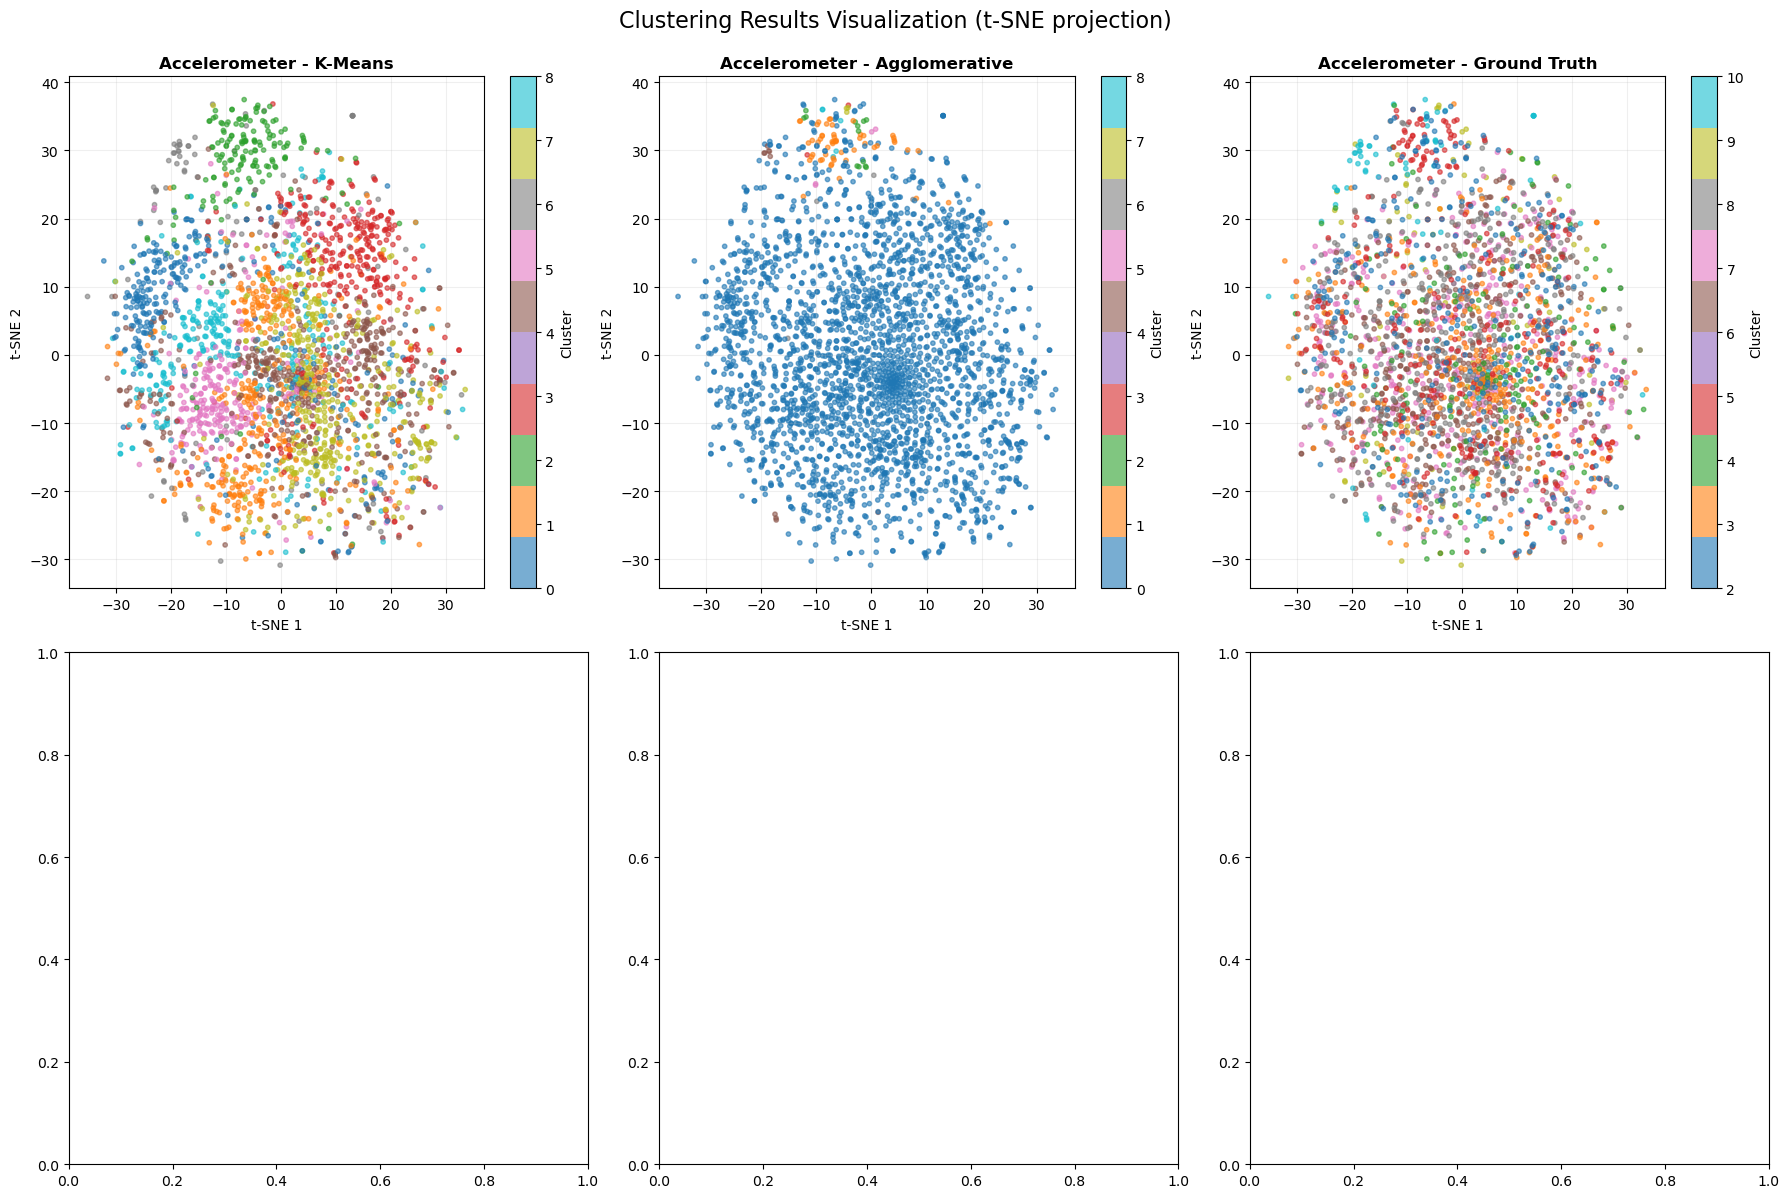

Visualization complete!


In [ ]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Reduce dimensions for visualization
print("Reducing embeddings to 2D using t-SNE...")
tsne_acc = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
tsne_gyro = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)

acc_tsne = tsne_acc.fit_transform(acc_emb_pca)
# gyro_tsne = tsne_gyro.fit_transform(gyro_emb_pca)

# Create comprehensive visualization
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('Clustering Results Visualization (t-SNE projection)', fontsize=16, y=0.995)

palette = cm.tab10

# Row 1: Accelerometer
# K-Means
axes[0, 0].scatter(acc_tsne[:, 0], acc_tsne[:, 1], c=labels_kmeans_acc, cmap=palette, alpha=0.6, s=10)
axes[0, 0].set_title('Accelerometer - K-Means', fontweight='bold')
axes[0, 0].set_xlabel('t-SNE 1')
axes[0, 0].set_ylabel('t-SNE 2')
axes[0, 0].grid(alpha=0.2)

# Agglomerative
axes[0, 1].scatter(acc_tsne[:, 0], acc_tsne[:, 1], c=labels_agg_acc, cmap=palette, alpha=0.6, s=10)
axes[0, 1].set_title('Accelerometer - Agglomerative', fontweight='bold')
axes[0, 1].set_xlabel('t-SNE 1')
axes[0, 1].set_ylabel('t-SNE 2')
axes[0, 1].grid(alpha=0.2)

# Ground Truth
axes[0, 2].scatter(acc_tsne[:, 0], acc_tsne[:, 1], c=acc_gt, cmap=palette, alpha=0.6, s=10)
axes[0, 2].set_title('Accelerometer - Ground Truth', fontweight='bold')
axes[0, 2].set_xlabel('t-SNE 1')
axes[0, 2].set_ylabel('t-SNE 2')
axes[0, 2].grid(alpha=0.2)

# Row 2: Gyroscope
# K-Means
# axes[1, 0].scatter(gyro_tsne[:, 0], gyro_tsne[:, 1], c=labels_kmeans_gyro, cmap=palette, alpha=0.6, s=10)
# axes[1, 0].set_title('Gyroscope - K-Means', fontweight='bold')
# axes[1, 0].set_xlabel('t-SNE 1')
# axes[1, 0].set_ylabel('t-SNE 2')
# axes[1, 0].grid(alpha=0.2)

# # Agglomerative
# axes[1, 1].scatter(gyro_tsne[:, 0], gyro_tsne[:, 1], c=labels_agg_gyro, cmap=palette, alpha=0.6, s=10)
# axes[1, 1].set_title('Gyroscope - Agglomerative', fontweight='bold')
# axes[1, 1].set_xlabel('t-SNE 1')
# axes[1, 1].set_ylabel('t-SNE 2')
# axes[1, 1].grid(alpha=0.2)

# # Ground Truth
# axes[1, 2].scatter(gyro_tsne[:, 0], gyro_tsne[:, 1], c=gyro_gt, cmap=palette, alpha=0.6, s=10)
# axes[1, 2].set_title('Gyroscope - Ground Truth', fontweight='bold')
# axes[1, 2].set_xlabel('t-SNE 1')
# axes[1, 2].set_ylabel('t-SNE 2')
# axes[1, 2].grid(alpha=0.2)


# Create a colorbar legend showing cluster-to-color mapping
fig.colorbar(axes[0, 0].collections[0], ax=axes[0, 0], label='Cluster')
fig.colorbar(axes[0, 1].collections[0], ax=axes[0, 1], label='Cluster')
fig.colorbar(axes[0, 2].collections[0], ax=axes[0, 2], label='Cluster')
# fig.colorbar(axes[1, 0].collections[0], ax=axes[1, 0], label='Cluster')
# fig.colorbar(axes[1, 1].collections[0], ax=axes[1, 1], label='Cluster')
# fig.colorbar(axes[1, 2].collections[0], ax=axes[1, 2], label='Cluster')

plt.tight_layout()
plt.show()

print("Visualization complete!")


In [ ]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import plotly.graph_objects as go

# ── 1. Flatten & convert embeddings ──────────────────────────────────────────
def flatten_embeddings(feature_embeddings):
    """Flatten list of dicts, handling nested dict values."""
    records = []
    for d in feature_embeddings:
        row = {}
        for k, v in d.items():
            if isinstance(v, dict):
                for sub_k, sub_v in v.items():
                    row[f"{k}_{sub_k}"] = sub_v
            else:
                row[k] = v
        records.append(row)
    return pd.DataFrame(records).values.astype(np.float64)

acc_emb_array  = flatten_embeddings(acc_feature_embeddings)
gyro_emb_array = flatten_embeddings(gyro_feature_embeddings)

print(f"Acc shape:  {acc_emb_array.shape}")
print(f"Gyro shape: {gyro_emb_array.shape}")

# ── 2. t-SNE → 3D ────────────────────────────────────────────────────────────
acc_tsne_3d  = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000).fit_transform(acc_emb_array)
gyro_tsne_3d = TSNE(n_components=3, random_state=42, perplexity=30, max_iter=1000).fit_transform(gyro_emb_array)

print("t-SNE done.")

# ── 3. Color palette & plot helper ───────────────────────────────────────────
COLORS = [
    '#e63946', '#457b9d', '#2a9d8f', '#e9c46a', '#f4a261',
    '#8338ec', '#06d6a0', '#fb8500', '#3a86ff', '#ff006e'
]

def make_3d_scatter(coords, labels, title):
    unique_labels = sorted(set(labels))
    traces = []
    for lbl in unique_labels:
        mask = np.array(labels) == lbl
        name  = "Noise" if lbl == -1 else f"Cluster {lbl}"
        color = '#aaaaaa' if lbl == -1 else COLORS[lbl % len(COLORS)]
        traces.append(go.Scatter3d(
            x=coords[mask, 0], y=coords[mask, 1], z=coords[mask, 2],
            mode='markers',
            name=name,
            marker=dict(size=4, color=color, opacity=0.75),
        ))
    fig = go.Figure(traces)
    fig.update_layout(
        title=dict(text=title, font=dict(size=14)),
        scene=dict(
            xaxis_title="t-SNE 1", yaxis_title="t-SNE 2", zaxis_title="t-SNE 3",
            bgcolor='rgb(15,15,25)',
            xaxis=dict(backgroundcolor='rgb(15,15,25)', gridcolor='rgba(255,255,255,0.1)'),
            yaxis=dict(backgroundcolor='rgb(15,15,25)', gridcolor='rgba(255,255,255,0.1)'),
            zaxis=dict(backgroundcolor='rgb(15,15,25)', gridcolor='rgba(255,255,255,0.1)'),
        ),
        paper_bgcolor='rgb(15,15,25)',
        font=dict(color='white'),
        legend=dict(bgcolor='rgba(255,255,255,0.05)', bordercolor='rgba(255,255,255,0.1)', borderwidth=1),
        margin=dict(l=0, r=0, t=40, b=0),
        height=500,
    )
    return fig

# ── 4. Plot all methods × both sensors ───────────────────────────────────────
configs = [
    (acc_tsne_3d,  labels_kmeans_acc,  "K-Means — Accelerometer"),
    (gyro_tsne_3d, labels_kmeans_gyro, "K-Means — Gyroscope"),
    (acc_tsne_3d,  labels_agg_acc,     "Agglomerative — Accelerometer"),
    (gyro_tsne_3d, labels_agg_gyro,    "Agglomerative — Gyroscope"),
    (acc_tsne_3d,  labels_dbscan_acc,  "DBSCAN — Accelerometer"),
    (gyro_tsne_3d, labels_dbscan_gyro, "DBSCAN — Gyroscope"),
]

for coords, labels, title in configs:
    make_3d_scatter(coords, labels, title).show()

Reducing embeddings to 3D using t-SNE...


TypeError: float() argument must be a string or a real number, not 'dict'